In [1]:
from pathlib import Path
import json

import numpy as np
import librosa
import librosa.display
import jams
import matplotlib.pyplot as plt

# Paths
PROJECT_ROOT = Path.cwd().parent  # notebooks/ is one level below project root
DATA_DIR = PROJECT_ROOT / "data" / "guitarset"
AUDIO_DIR = DATA_DIR / "audio_mono-mic"
ANNO_DIR = DATA_DIR / "annotation"

# Sanity check
print(f"Audio files: {len(list(AUDIO_DIR.glob('*.wav')))}")
print(f"Annotation files: {len(list(ANNO_DIR.glob('*.jams')))}")

Audio files: 360
Annotation files: 360


In [3]:
# List first 15 audio files to see the actual naming
audio_files = sorted(AUDIO_DIR.glob("*.wav"))
print(f"Total audio files: {len(audio_files)}\n")
print("First 15 filenames:")
for f in audio_files[:15]:
    print(f"  {f.name}")

Total audio files: 360

First 15 filenames:
  00_BN1-129-Eb_comp_mic.wav
  00_BN1-129-Eb_solo_mic.wav
  00_BN1-147-Gb_comp_mic.wav
  00_BN1-147-Gb_solo_mic.wav
  00_BN2-131-B_comp_mic.wav
  00_BN2-131-B_solo_mic.wav
  00_BN2-166-Ab_comp_mic.wav
  00_BN2-166-Ab_solo_mic.wav
  00_BN3-119-G_comp_mic.wav
  00_BN3-119-G_solo_mic.wav
  00_BN3-154-E_comp_mic.wav
  00_BN3-154-E_solo_mic.wav
  00_Funk1-114-Ab_comp_mic.wav
  00_Funk1-114-Ab_solo_mic.wav
  00_Funk1-97-C_comp_mic.wav


In [4]:
# Pick a "comp" file (chord playing) from player 00
FILE_ID = "00_BN1-129-Eb_comp"

audio_path = AUDIO_DIR / f"{FILE_ID}_mic.wav"   # audio has _mic suffix
anno_path = ANNO_DIR / f"{FILE_ID}.jams"        # annotation does not

print(f"Audio exists: {audio_path.exists()}")
print(f"Anno exists:  {anno_path.exists()}")

# Load audio
y, sr = librosa.load(audio_path, sr=22050, mono=True)

print(f"\nAudio shape: {y.shape}")
print(f"Sample rate: {sr} Hz")
print(f"Duration:    {len(y) / sr:.2f} seconds")
print(f"Amplitude range: [{y.min():.3f}, {y.max():.3f}]")

Audio exists: True
Anno exists:  True

Audio shape: (492253,)
Sample rate: 22050 Hz
Duration:    22.32 seconds
Amplitude range: [-0.280, 0.278]


In [6]:
# Load the JAMS annotation
jam = jams.load(str(anno_path))

# What annotation types are in this file?
print("Annotations in this JAMS file:")
for i, ann in enumerate(jam.annotations):
    dur_str = f"{ann.duration:.2f}s" if ann.duration is not None else "None"
    print(f"  [{i}] namespace='{ann.namespace}', "
          f"num_observations={len(ann.data)}, "
          f"duration={dur_str}")

Annotations in this JAMS file:
  [0] namespace='pitch_contour', num_observations=710, duration=22.32s
  [1] namespace='note_midi', num_observations=7, duration=22.32s
  [2] namespace='pitch_contour', num_observations=1964, duration=22.32s
  [3] namespace='note_midi', num_observations=23, duration=22.32s
  [4] namespace='pitch_contour', num_observations=2164, duration=22.32s
  [5] namespace='note_midi', num_observations=33, duration=22.32s
  [6] namespace='pitch_contour', num_observations=2342, duration=22.32s
  [7] namespace='note_midi', num_observations=36, duration=22.32s
  [8] namespace='pitch_contour', num_observations=1648, duration=22.32s
  [9] namespace='note_midi', num_observations=25, duration=22.32s
  [10] namespace='pitch_contour', num_observations=878, duration=22.32s
  [11] namespace='note_midi', num_observations=9, duration=22.32s
  [12] namespace='beat_position', num_observations=48, duration=22.32s
  [13] namespace='tempo', num_observations=1, duration=22.32s
  [14] nam

In [9]:
from typing import cast
from jams import Annotation

# jam.search() returns list[Unknown] to Pylance; cast to make the type explicit
chord_ann = cast(Annotation, jam.search(namespace="chord")[0])

print(f"Chord annotation duration: {chord_ann.duration}s")
print(f"Number of chord observations: {len(chord_ann.data)}\n")

print("Chord segments:")
print(f"{'time':>8}  {'duration':>10}  {'value':>10}")
print("-" * 34)
for obs in chord_ann.data:
    print(f"{obs.time:>8.3f}  {obs.duration:>10.3f}  {obs.value:>10}")

Chord annotation duration: 22.32439999999997s
Number of chord observations: 6

Chord segments:
    time    duration       value
----------------------------------
   0.000       7.442      D#:maj
   7.442       3.721      G#:maj
  11.163       3.721      D#:maj
  14.884       1.860      A#:maj
  16.744       1.860      G#:maj
  18.605       3.720      D#:maj


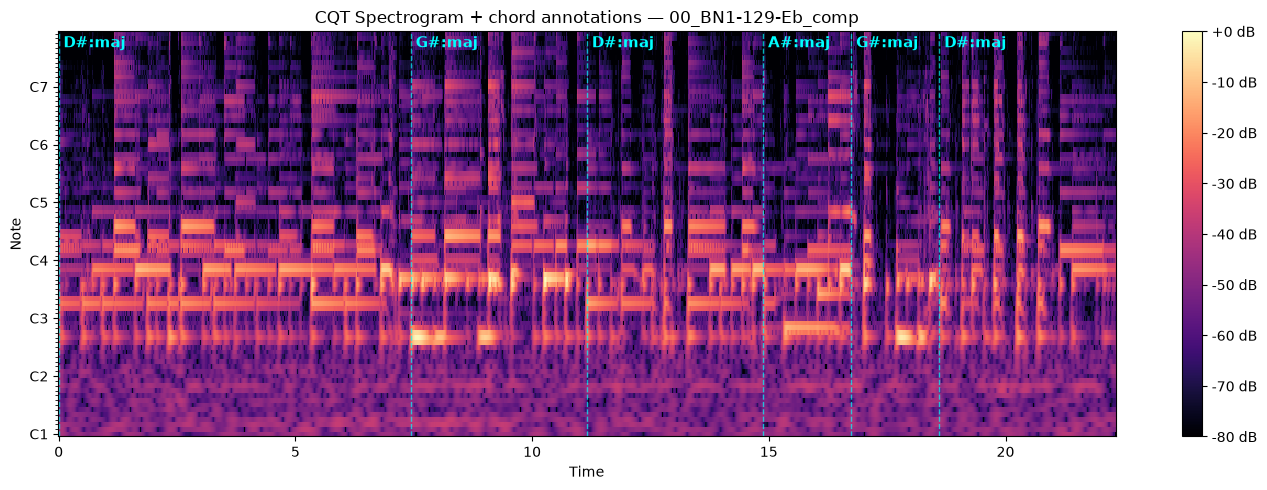

In [10]:
# Compute CQT (Constant-Q Transform) — this is what our CNN will eventually see
# 84 bins = 7 octaves, 12 bins per octave (one per semitone)
C = np.abs(librosa.cqt(y, sr=sr, n_bins=84, bins_per_octave=12))
C_db = librosa.amplitude_to_db(C, ref=np.max)

# Plot the CQT and overlay the chord segments
fig, ax = plt.subplots(figsize=(14, 5))
img = librosa.display.specshow(
    C_db,
    sr=sr,
    x_axis="time",
    y_axis="cqt_note",
    ax=ax,
    cmap="magma",
)
fig.colorbar(img, ax=ax, format="%+2.0f dB")

# Overlay chord boundaries + labels
for obs in chord_ann.data:
    ax.axvline(obs.time, color="cyan", linestyle="--", linewidth=1, alpha=0.7)
    ax.text(
        obs.time + 0.1,
        ax.get_ylim()[1] * 0.95,
        obs.value,
        color="cyan",
        fontsize=11,
        fontweight="bold",
        verticalalignment="top",
    )

ax.set_title(f"CQT Spectrogram + chord annotations — {FILE_ID}")
plt.tight_layout()
plt.show()